# 🇪🇬 Digitamart Orders Data Analysis

**Author:** Ahmed Mostafa Abdallah

## Project Overview
This project analyzes Digitamart orders using Python.

### Objectives
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights


# 📚 Import Libraries

student : ahmed mostafa abdallah abdallah

id : 31103011310097

project name : Digitamart_orders

In [252]:
# Loading the Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Reading the csv_file
df = pd.read_csv("digitamart_orders.csv")
print(df.head(10))

   order_id  order_date   city  product_category      product_name  \
0      1001  2024-11-23  Cairo       Electronics       USB-C Cable   
1      1002  2024-08-04  Cairo  Food & Groceries      Olive Oil 1L   
2      1003  2025-01-30   Giza  Food & Groceries         Spice Set   
3      1004  2024-06-10   Giza          Clothing      Leather Belt   
4      1005  2024-01-25  Aswan       Electronics        Power Bank   
5      1006  2025-01-04  Cairo             Books   Self-Help Guide   
6      1007  2024-10-17  Aswan          Clothing      Denim Jacket   
7      1008  2024-09-21  cairo          Clothing      Summer Dress   
8      1009  2024-08-30   GIZA             Books      History Book   
9      1010  2024-02-08  Aswan       Electronics  Wireless Earbuds   

   order_total  delivery_minutes  customer_rating payment_method  customer_age  
0       425.15              26.0              5.0         Wallet          18.0  
1       232.62             137.0              4.0         Wallet   

In [253]:
# Data's Size
print("Rows , Columns :", df.shape)
print()
# Names of every column
print("Columns name :")
for col in df.columns:
  print(col)

Rows , Columns : (326, 10)

Columns name :
order_id
order_date
city
product_category
product_name
order_total
delivery_minutes
customer_rating
payment_method
customer_age


## Description of the data:

1.   This dataset contains orders from the Digitamart store.

2.   Each row represents one order that a customer purchased from the store.

3.   A numeric column is "order_total".

4.   A text column is "city".

In [254]:
# Shape
print("Shape:")
print(df.shape)
print()
# Types
print("Data Types:")
print(df.dtypes)
print()
# Information
print("Info:")
df.info(show_counts=True)
print()
# Missing values
print("Missing Values:")
print(df.isna())
print("Missing Values number:")
print(df.isna().sum())
print()
# Duplicates
print("Duplicate Rows:")
print(df.duplicated())
print("Duplicate Rows number:", df.duplicated().sum())
print()
# Summary statistics
print("Summary Statistics:")
print(df.describe())

Shape:
(326, 10)

Data Types:
order_id              int64
order_date           object
city                 object
product_category     object
product_name         object
order_total         float64
delivery_minutes    float64
customer_rating     float64
payment_method       object
customer_age        float64
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          326 non-null    int64  
 1   order_date        320 non-null    object 
 2   city              324 non-null    object 
 3   product_category  326 non-null    object 
 4   product_name      326 non-null    object 
 5   order_total       324 non-null    float64
 6   delivery_minutes  324 non-null    float64
 7   customer_rating   321 non-null    float64
 8   payment_method    326 non-null    object 
 9   customer_age      324 non-null    float64


## Problems Found:


1.   There are 4 columns of type "float64""int64",one column of type "int64",5 columns of type "object".

2.   There are 19 missing values such as :
*   order_date has 6
*   city has 2
*   order_total has 2
*   delivery_minutes has 2
*   customer_rating has 5
*   customer_age has 2

3.   There are 6 rows has been duplicated.

4.   There is a missing value in city column

In [255]:
#  Drop_duplicates
print("Duplicate rows:", df.duplicated().sum())
print("*" * 50)

before = len(df)

df = df.drop_duplicates()
df = df.reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("/" * 50)
print("Rows after :", after)
print("-" * 50)

Duplicate rows: 6
**************************************************
Rows before: 326
//////////////////////////////////////////////////
Rows after : 320
--------------------------------------------------


In [256]:
# Standardise cities
print("Before:", df["city"].unique())
print("Before count:", df["city"].nunique())

df["city"] = df["city"].str.strip().str.title()
city_map = {
    "cairo": "Cairo", "CAIRO": "Cairo", "Cairo ": "Cairo",
    "alex": "Alexandria", "Alex": "Alexandria",
    "giza": "Giza", "GIZA": "Giza",
    "mansoura": "Mansoura", "Mansoura": "Mansoura"
    }
df["city"] = df["city"].replace(city_map)

print("After:", df["city"].unique())
print("After count:", df["city"].nunique())

Before: ['Cairo' 'Giza' 'Aswan' 'cairo' 'GIZA' 'Alexandria' 'Mansoura' 'CAIRO'
 'mansoura' nan 'alexandria']
Before count: 10
After: ['Cairo' 'Giza' 'Aswan' 'Alexandria' 'Mansoura' nan]
After count: 5


In [257]:
# Missing values
print("Before fixing:")
print(df.isna())
print()
print(df.isna().sum())
print()

df["order_date"] = df["order_date"].fillna(df["order_date"].mode()[0])

df["city"] = df["city"].fillna(df["city"].mode()[0])

df["delivery_minutes"] = df["delivery_minutes"].fillna(df["delivery_minutes"].mode()[0])

df["order_total"] = df["order_total"].fillna(df["order_total"].median())

df["customer_rating"] = df["customer_rating"].fillna(df["customer_rating"].median())

df["customer_age"] = df["customer_age"].fillna(df["customer_age"].median())

print("After fixing:")
print(df.isna())
print()
print(df.isna().sum())

Before fixing:
     order_id  order_date   city  product_category  product_name  order_total  \
0       False       False  False             False         False        False   
1       False       False  False             False         False        False   
2       False       False  False             False         False        False   
3       False       False  False             False         False        False   
4       False       False  False             False         False        False   
..        ...         ...    ...               ...           ...          ...   
315     False       False  False             False         False        False   
316     False       False  False             False         False        False   
317     False       False  False             False         False        False   
318     False       False  False             False         False        False   
319     False       False  False             False         False        False   

     deliver

In [258]:
# Standardise cities after fill nan
df["city"] = df["city"].str.strip().str.title()
city_map = {
    "cairo": "Cairo", "CAIRO": "Cairo", "Cairo ": "Cairo",
    "alex": "Alexandria", "Alex": "Alexandria",
    "giza": "Giza", "GIZA": "Giza",
    "mansoura": "Mansoura", "Mansoura": "Mansoura"
    }
df["city"] = df["city"].replace(city_map)

print("After fill nan:", df["city"].unique())
print("After count:", df["city"].nunique())

After fill nan: ['Cairo' 'Giza' 'Aswan' 'Alexandria' 'Mansoura']
After count: 5


In [259]:
# Outliers
Q1 = df["order_total"].quantile(0.25)
Q3 = df["order_total"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower bound:", round(lower,2))
print()
print("Upper bound:", round(upper,2))
print()
affected = ((df["order_total"] < lower) |
            (df["order_total"] > upper)).sum()

df["order_total"] = df["order_total"].clip(lower=lower, upper=upper)
print("Rows affected:", affected)

Lower bound: -1360.43

Upper bound: 2885.66

Rows affected: 30


In [260]:
df.to_csv("Digitamart_orders_clean.csv", index=False)

In [261]:
# Loading the Clean File
df = pd.read_csv("Digitamart_orders_clean.csv")

In [262]:
# summary statistics
print(df.describe().round(2))

       order_id  order_total  delivery_minutes  customer_rating  customer_age
count    320.00       320.00            320.00           320.00        320.00
mean    1160.50       861.48            115.59             3.10         43.23
std       92.52       904.26            125.46             1.39         15.55
min     1001.00      -322.35             22.00             0.00         18.00
25%     1080.75       231.86             60.75             2.00         30.00
50%     1160.50       398.16            104.50             3.00         45.00
75%     1240.25      1293.38            139.25             4.00         55.25
max     1320.00      2885.66           1181.00             5.00        150.00


**Goals:**


1.   Which city has the highest average order total?

2.   How does the average order total vary across customer ages?

3.   Is there a relationship between delivery time and customer rating?

In [263]:
print("+++++ answers by pandas +++++")
print("===== Goal 1 =====")

print("Goal 1.answer :")
print("-" * 50)

avg_order = df.groupby("city")["order_total"].mean().sort_values(ascending=False)
print(avg_order.round(2))
print("-" * 50)

print("Town name:", avg_order.idxmax())
print("." * 50)
print("Average value:", round(avg_order.max(), 2), "EGP")

+++++ answers by pandas +++++
===== Goal 1 =====
Goal 1.answer :
--------------------------------------------------
city
Aswan         1063.27
Giza           870.90
Cairo          863.15
Alexandria     852.00
Mansoura       658.99
Name: order_total, dtype: float64
--------------------------------------------------
Town name: Aswan
..................................................
Average value: 1063.27 EGP


In [264]:
# The most commom pay method
print(df["payment_method"].value_counts())

payment_method
Bank Transfer    83
Wallet           77
Credit Card      76
Cash             69
cash              8
wallet            3
bank transfer     2
credit card       2
Name: count, dtype: int64


The last cell represent the city has the highest average order total which is Aswan with total equal 1063.27 EGP.

In [265]:
print("+++++ answers by pandas +++++")
print("===== Goal 2 =====")

print("Goal 2.answer :")
print("-" * 50)

customer_age = df.groupby("customer_age")["order_total"].mean().sort_index()

print(customer_age.round(2))

+++++ answers by pandas +++++
===== Goal 2 =====
Goal 2.answer :
--------------------------------------------------
customer_age
18.0      766.27
19.0      333.62
20.0      733.09
21.0      744.03
22.0      510.16
23.0      578.79
24.0     1660.97
25.0     1341.60
26.0      968.60
27.0      917.56
28.0     1110.01
29.0      164.64
30.0     1042.75
31.0      952.57
32.0     1112.35
33.0      378.69
34.0      309.00
35.0      682.20
36.0     1082.76
37.0      857.21
38.0     1045.23
39.0      793.28
40.0     1382.31
41.0     1042.62
42.0      957.23
43.0      716.94
44.0     1164.99
45.0      955.47
46.0      164.38
47.0      761.15
48.0      616.99
49.0     1120.14
50.0      597.48
51.0     1296.33
52.0      801.03
53.0      627.70
54.0      632.75
55.0     1241.25
56.0      485.53
57.0      968.48
58.0      532.67
59.0      566.45
60.0     1407.35
61.0      817.07
62.0     1124.60
63.0      968.79
64.0      874.05
65.0      993.65
150.0    2885.66
Name: order_total, dtype: float64


The last cell represent how the average order total varies across customer ages.

There is an outliers which is 150 in customer_age column that has the largest order_total.

In [266]:
# Drop the outlier of ages
Q1 = df["customer_age"].quantile(0.25)
Q3 = df["customer_age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower bound:", round(lower,2))
print()
print("Upper bound:", round(upper,2))
print()
affected = ((df["customer_age"] < lower) |
            (df["customer_age"] > upper)).sum()

df["customer_age"] = df["customer_age"].clip(lower=lower, upper=upper)
print("Rows affected:", affected)

Lower bound: -7.88

Upper bound: 93.12

Rows affected: 1


In [267]:
print("+++++ answers by pandas +++++")
print("===== Goal 3 ====")

print("Goal 3.answer :")
print("-" * 50)

correlation = df["delivery_minutes"].corr(df["customer_rating"])

print("Correlation:", correlation.round(2))
print("*" * 50)

+++++ answers by pandas +++++
===== Goal 3 ====
Goal 3.answer :
--------------------------------------------------
Correlation: 0.02
**************************************************


The last cell represent the relation between "delivery_minutes" and "customer_rating" which equals 0.02 which represent a weak positive relationship.

+++++ answers by matplotlip +++++
===== Goal 1 ====
Goal 1.answer :
--------------------------------------------------


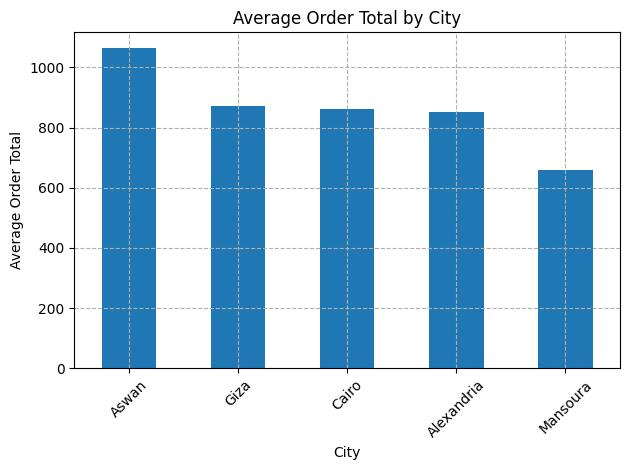

In [268]:
print("+++++ answers by matplotlip +++++")

print("===== Goal 1 ====")

print("Goal 1.answer :")
print("-" * 50)

avg_order = df.groupby("city")["order_total"].mean().sort_values(ascending=False)

avg_order.plot(kind="bar")
plt.title("Average Order Total by City")
plt.xlabel("City")
plt.ylabel("Average Order Total")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

+++++ answers by matplotlip +++++
===== Goal 2 ====
Goal 2.answer :
--------------------------------------------------


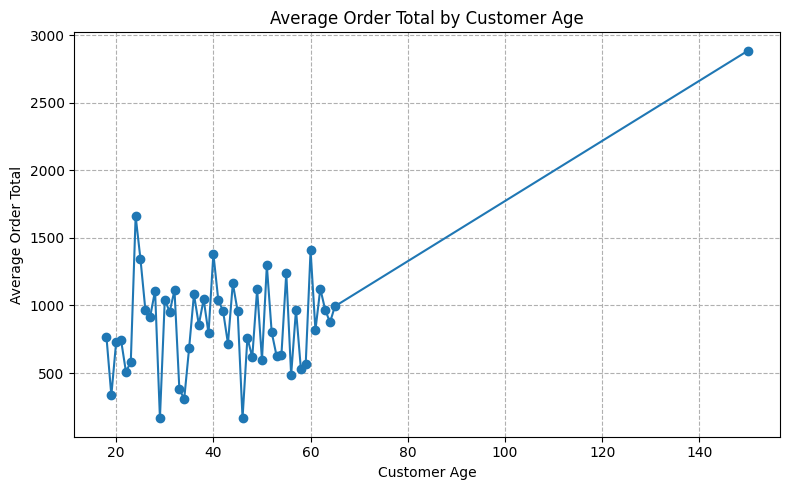

In [269]:
print("+++++ answers by matplotlip +++++")
print("===== Goal 2 ====")

print("Goal 2.answer :")
print("-" * 50)
customer_age.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Average Order Total by Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Average Order Total")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

+++++ answers by matplotlip +++++
===== Goal 3 ====
Goal 3.answer :
--------------------------------------------------


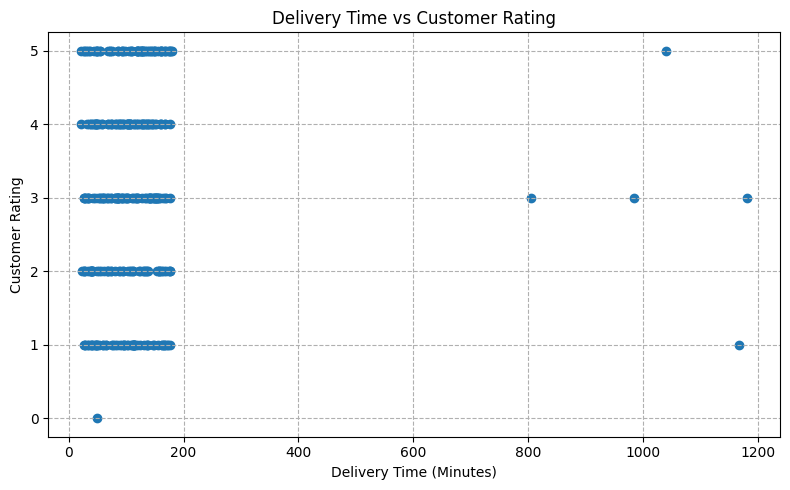

In [270]:
print("+++++ answers by matplotlip +++++")
print("===== Goal 3 ====")

print("Goal 3.answer :")
print("-" * 50)


plt.figure(figsize=(8,5))

plt.scatter(df["delivery_minutes"], df["customer_rating"])

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Customer Rating")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

## Summarise results:

1.  There is a big outlier in the column "customer_ages" which causes the ages from 18 to 65 to appear compressed into a small section of the graph.

2.   There is a weak relation ship between "delivery_minutes" and "customer_rating" which equals 0.02 .

3.   Isuggest that it's a must to know why Mansoura has the smallest avrage order total .



Insight 1

Observation: Aswan has the highest average order total.

Evidence: The average order total in Alexandria is 1063.27 EGP.

Implication: The store can focus more marketing campaigns and premium products in Aswan to increase sales.

Hypothesis 1:

Why do customers in Aswan spend more per order than customers in other cities?

Insight 2

Observation: Bank Transfer is the most popular payment method.

Evidence: It was used in 83 orders.

Implication: The store should ensure the Bank Transfer payment option is always available and easy to use.

Hypothesis 2:

Would improving the Bank Transfer payment process increase the number of completed orders?